In [104]:

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
#import seaborn as sns


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [105]:
df = pd.read_csv(r'data\telco_info.csv')

In [106]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [107]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [108]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# EDA

**Distribuição da variável alvo (Churn)** 
Clientes que abandonaram o serviço no último mês (coluna Churn)


/tmp/ipykernel_57/3229865273.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn', data = df, palette='viridis')


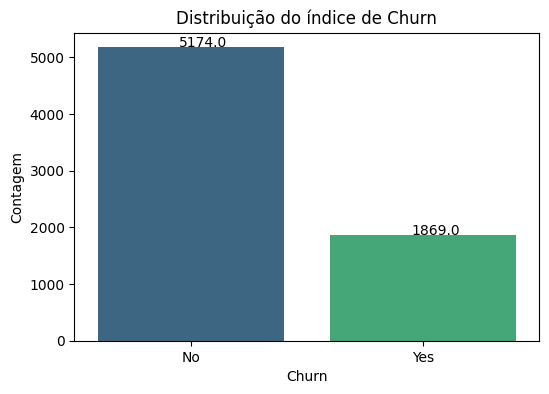

In [12]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x='Churn', data = df, palette='viridis')

plt.title('Distribuição do índice de Churn')
plt.xlabel('Churn')
plt.ylabel('Contagem')

# Adicionar rotulos nas barras
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + 0.35, p.get_height() + 5))



**Churn por Tipo de Contrato**

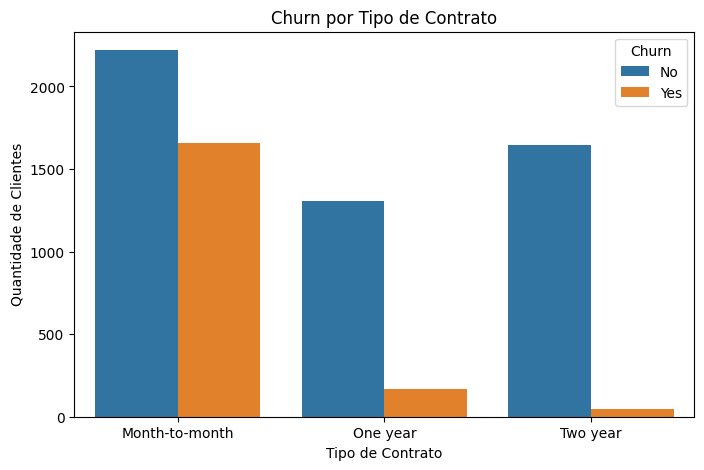

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue="Churn", data = df)

plt.title('Churn por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel("Quantidade de Clientes")
plt.legend(title="Churn", loc="upper right")

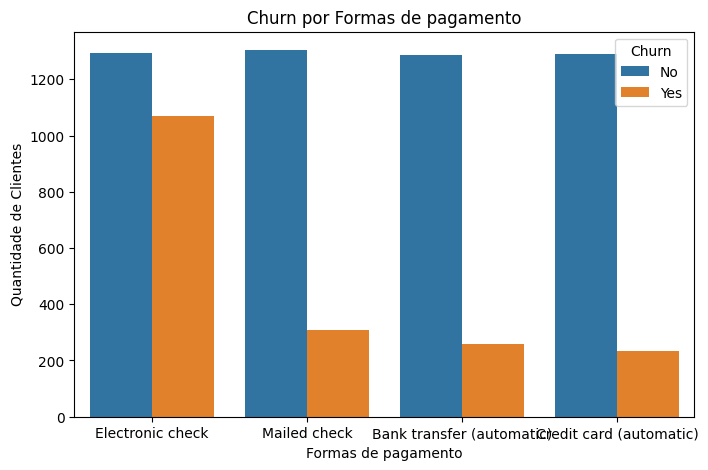

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(x='PaymentMethod', hue="Churn", data = df)

plt.title('Churn por Formas de pagamento')
plt.xlabel('Formas de pagamento')
plt.ylabel("Quantidade de Clientes")
plt.legend(title="Churn", loc="upper right")

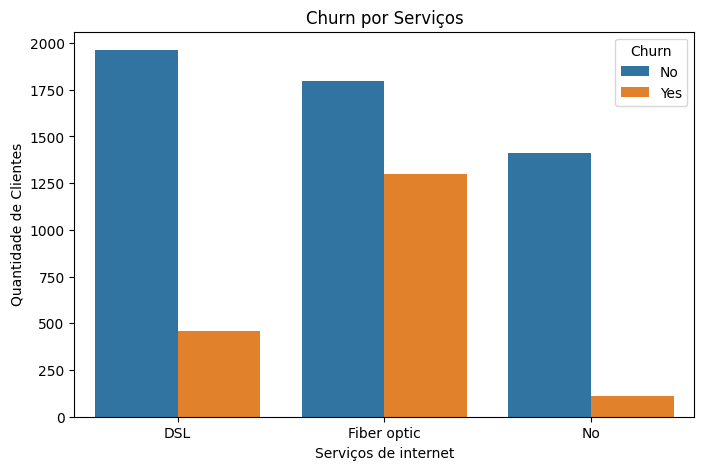

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(x='InternetService', hue="Churn", data = df)

plt.title('Churn por Serviços')
plt.xlabel('Serviços de internet')
plt.ylabel("Quantidade de Clientes")
plt.legend(title="Churn", loc="upper right")

**Churn por Tempo de Cliente e Valor Pago**

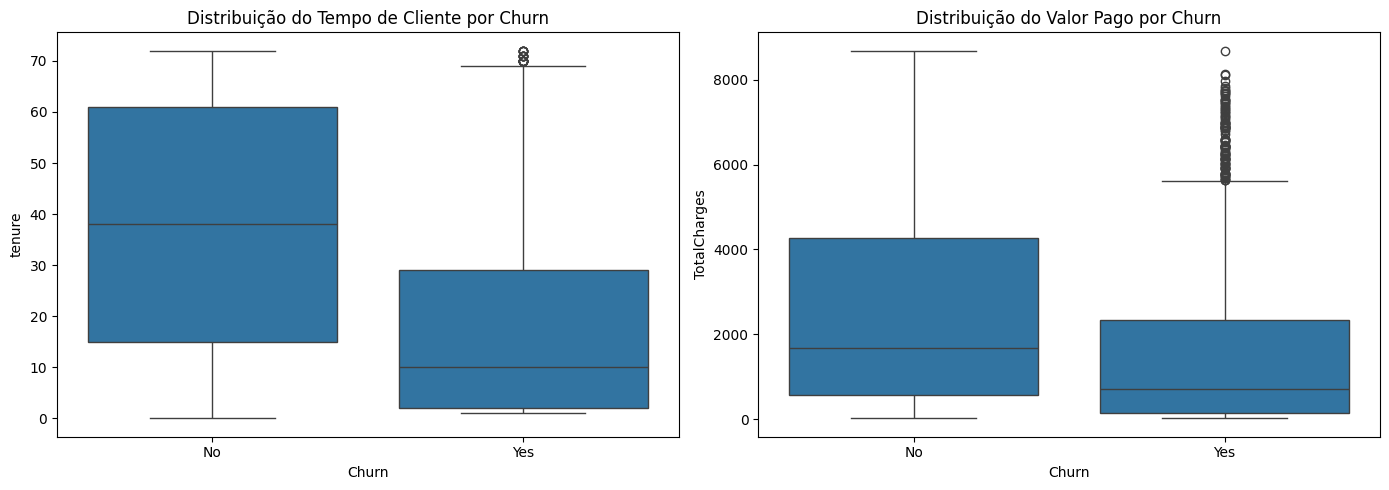

In [16]:
fig, axes = plt.subplots(1,2, figsize=(14,5))
sns.boxplot(x="Churn", y='tenure', data=df, ax=axes[0])
axes[0].set_title('Distribuição do Tempo de Cliente por Churn')

sns.boxplot(x='Churn', y='TotalCharges', data=df, ax=axes[1])
axes[1].set_title("Distribuição do Valor Pago por Churn")

plt.tight_layout()



**Correlação entre Variáveis**

Text(0.5, 1.0, 'Mapa de Correlação')

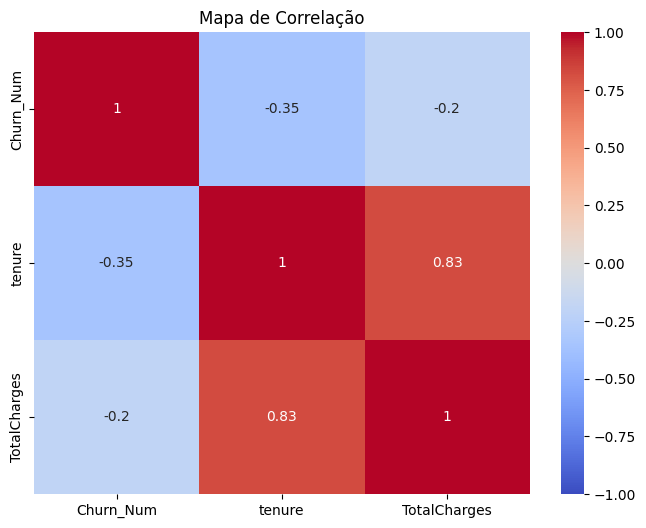

In [17]:
df_corr = df.copy()
df_corr['Churn_Num'] = df_corr['Churn'].apply(lambda x:1 if x=='Yes' else 0)

cols = ['Churn_Num', 'tenure', 'TotalCharges']
matriz_correlacao = df_corr[cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Mapa de Correlação')


In [109]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [110]:
df['TotalCharges'].fillna(0, inplace=True)
df.isnull().sum()

C:\Users\millena.pereira\AppData\Local\Temp\ipykernel_2036\2526459145.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['TotalCharges'].fillna(0, inplace=True)


customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

**Identificando e Tratando Outliers**

In [111]:
def limites_outliers(coluna):
    Q1 = coluna.quantile(0.25)
    Q3 = coluna.quantile(0.75)
    IQR = Q3-Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    return limite_inferior, limite_superior

lim_inf, lim_sup = limites_outliers(df['TotalCharges'])

In [112]:
print(f"Limites para Valor Pago: {lim_inf:.2f} a {lim_sup:.2f}")

Limites para Valor Pago: -4688.48 a 8884.67


In [113]:
outliers = df[(df['TotalCharges']<lim_inf) | df['TotalCharges']>lim_sup]
print(f"{len(outliers)} outliers")

0 outliers


# Data Preparation


In [114]:
bins = [0,12,24,48,72]
labels = ['0-1 Ano', '1-2 Anos', '2-4 Anos', '4-6 Anos']

df['Tenure_Faixa'] = pd.cut(df['tenure'], bins = bins, labels=labels, right =True)
df['Tenure_Faixa'] = pd.cut(df['tenure'], bins=[-1, 12, 24, 48, 73], labels=labels)
df['Tenure_Faixa'].value_counts()

Tenure_Faixa
4-6 Anos    2239
0-1 Ano     2186
2-4 Anos    1594
1-2 Anos    1024
Name: count, dtype: int64

In [115]:
df['Ticket_Medio_Historico'] = df.apply(lambda x: x['TotalCharges']/x['tenure'] if x['tenure'] > 0 else x['MonthlyCharges'], axis=1 )

In [116]:
genero = {'Female':1, 'Male':0}
binario = {'Yes':1, 'No':0}

colunas_binarias = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
for col in colunas_binarias:
    df[col] = df[col].map(binario)

df['gender'] = df['gender'].map(genero)

In [117]:
cols_one_hot = ['InternetService', 'Contract', 'PaymentMethod', 'Tenure_Faixa']
df_final = pd.get_dummies(df, columns=cols_one_hot, drop_first = True)
bool_cols = df_final.select_dtypes(include=['bool']).columns
df_final[bool_cols] = df_final[bool_cols].astype(int)


In [118]:
cols_texto = [
    'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]
for col in cols_texto:
    df_final[col] = df_final[col].replace({'No internet service': 'No', 'No phone service': 'No'})

    df_final[col] = df_final[col].map({'Yes': 1, 'No': 0})

In [119]:
df_final.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,...,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Tenure_Faixa_1-2 Anos,Tenure_Faixa_2-4 Anos,Tenure_Faixa_4-6 Anos
0,7590-VHVEG,1,0,1,0,1,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
1,5575-GNVDE,0,0,0,0,34,1,0,1,0,...,0,0,1,0,0,0,1,0,1,0
2,3668-QPYBK,0,0,0,0,2,1,0,1,1,...,0,0,0,0,0,0,1,0,0,0
3,7795-CFOCW,0,0,0,0,45,0,0,1,0,...,0,0,1,0,0,0,0,0,1,0
4,9237-HQITU,1,0,0,0,2,1,0,0,0,...,1,0,0,0,0,1,0,0,0,0


In [121]:
list(df_final.columns)

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'PaperlessBilling',
 'MonthlyCharges',
 'TotalCharges',
 'Churn',
 'Ticket_Medio_Historico',
 'InternetService_Fiber optic',
 'InternetService_No',
 'Contract_One year',
 'Contract_Two year',
 'PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Mailed check',
 'Tenure_Faixa_1-2 Anos',
 'Tenure_Faixa_2-4 Anos',
 'Tenure_Faixa_4-6 Anos']

In [122]:
features = df_final.drop(columns=['customerID', 'Churn', 'Tenure_Faixa_1-2 Anos', 'Tenure_Faixa_2-4 Anos', 'Tenure_Faixa_4-6 Anos']).columns.copy()
target = 'Churn'
X, y = df_final[features], df_final[target]


# Modelagem

In [123]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Treino: {X_train.shape}, Teste: {X_test.shape}")

Treino: (5634, 24), Teste: (1409, 24)


In [124]:
X_train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Ticket_Medio_Historico,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3738,0,0,0,0,35,0,0,0,0,1,...,49.20,1701.65,48.618571,0,0,0,0,0,1,0
3151,0,0,1,1,15,1,0,1,0,0,...,75.10,1151.55,76.770000,1,0,0,0,0,0,1
4860,0,0,1,1,13,0,0,1,1,0,...,40.55,590.35,45.411538,0,0,0,1,0,0,1
3867,1,0,1,0,26,1,0,0,1,1,...,73.50,1905.70,73.296154,0,0,0,1,1,0,0
3810,0,0,1,1,1,1,0,0,0,0,...,44.55,44.55,44.550000,0,0,0,0,0,1,0


In [96]:
df_analise = X_train.copy()
df_analise[target] = y_train
sumario = df_analise.groupby(by=target).agg(['mean', "median"]).T

sumario['diff_abs'] = sumario[0]-sumario[1]
sumario['diff_rel'] = sumario[0]/sumario[1] 

sumario.sort_values(by='diff_rel', ascending=False)

,Churn,0,1,diff_abs,diff_rel
Partner,median,1.000000,0.000000,1.000000,inf
Contract_Two year,mean,0.318918,0.026087,0.292831,12.225175
InternetService_No,mean,0.272046,0.058863,0.213184,4.621697
tenure,median,38.000000,10.000000,28.000000,3.800000
Contract_One year,mean,0.251993,0.086957,0.165037,2.897922
TotalCharges,median,1691.900000,740.300000,951.600000,2.285425
OnlineSecurity,mean,0.335588,0.156522,0.179067,2.144036
PaymentMethod_Credit card (automatic),mean,0.249336,0.121070,0.128265,2.059429
tenure,mean,37.587582,18.358528,19.229053,2.047418
TechSupport,mean,0.338004,0.167224,0.170780,2.021266


In [ ]:
from sklearn import tree

arvore = tree.DecisionTreeClassifier(random_state=42)
arvore.fit(X_train, y_train)

arvore.feature_importances_

array([0.02102389, 0.01507603, 0.01964513, 0.01854039, 0.16574898,
       0.0051343 , 0.01340954, 0.01917273, 0.0123507 , 0.00979249,
       0.01474177, 0.01029151, 0.00299071, 0.02238448, 0.13452268,
       0.17934672, 0.14461179, 0.11309912, 0.01203531, 0.01173779,
       0.00988249, 0.01075673, 0.02612067, 0.00758404])

In [144]:
feature_importance = pd.Series(arvore.feature_importances_, index=X_train.columns).sort_values(ascending=False).reset_index()
feature_importance['acumulada'] = feature_importance[0].cumsum()
feature_importance[feature_importance[0]>0.01]


,index,0,acumulada
0,TotalCharges,0.179347,0.179347
1,tenure,0.165749,0.345096
2,Ticket_Medio_Historico,0.144612,0.489707
3,MonthlyCharges,0.134523,0.624230
4,InternetService_Fiber optic,0.113099,0.737329
5,PaymentMethod_Electronic check,0.026121,0.763450
6,PaperlessBilling,0.022384,0.785834
7,gender,0.021024,0.806858
8,Partner,0.019645,0.826503
9,OnlineSecurity,0.019173,0.845676


In [98]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.pipeline import Pipeline

def executar_modelo(modelo, nome, X_train, y_train, X_test,y_test):
    pipe = Pipeline([('scaler', StandardScaler()), ('model', modelo)])

    #Treino
    pipe.fit(X_train, y_train)

    #teste
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:,1]

    #Métricas
    print(f"{nome}")
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC: {roc_auc_score(y_test,y_prob)}")

    #Matriz de coonfusão
    plt.figure(figsize=(5,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot = True, fmt ='d', cmap='Blues')
    plt.title(f"Matriz de confusão - {nome}")
    plt.show()

    return pipe

**Logistic Regression**

In [99]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)

pipe_lr = executar_modelo(model_lr, 'Logistic Regression', X_train, y_train, X_test, y_test)

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

**Random Forest**

Random Forest
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1552
           1       0.64      0.46      0.53       561

    accuracy                           0.79      2113
   macro avg       0.73      0.68      0.70      2113
weighted avg       0.77      0.79      0.77      2113

ROC-AUC: 0.8243787557197199


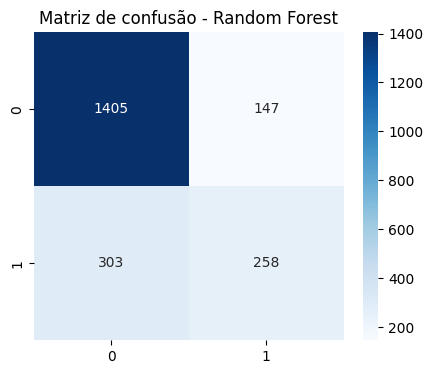

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)

pipe_rf = executar_modelo(model_rf, "Random Forest", X_train, y_train, X_test, y_test)

**Gradient Boosting**

Gradient Boosting
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1552
           1       0.64      0.49      0.55       561

    accuracy                           0.79      2113
   macro avg       0.73      0.69      0.71      2113
weighted avg       0.78      0.79      0.78      2113

ROC-AUC: 0.8400804206406086


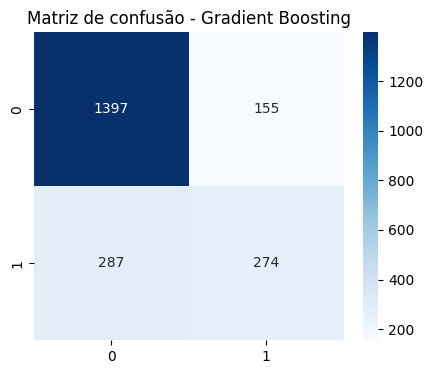

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

model_gb = GradientBoostingClassifier(random_state=42)

pipe_gb = executar_modelo(model_gb, "Gradient Boosting", X_train, y_train, X_test, y_test)

**Cross-Validation**

In [ ]:
from sklearn.model_selection import cross_val_score

modelos = [
    ('LogReg', LogisticRegression(class_weight='balanced', max_iter=1000)),
    ('RandomForest', RandomForestClassifier(class_weight='balanced')),
    ('GradBoost', GradientBoostingClassifier())
]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

print("Cross-Validation (Média ROC-AUC)")
for nome, model in modelos:
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='roc_auc')
    print(f"{nome}: {scores.mean():.4f} (+/- {scores.std():.4f})")

Cross-Validation (Média ROC-AUC)
LogReg: 0.8463 (+/- 0.0110)
RandomForest: 0.8297 (+/- 0.0118)
GradBoost: 0.8443 (+/- 0.0139)


# Avaliação dos modelos

In [ ]:
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score

def get_metrics(modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:,1]
    return{
        'Recall': recall_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

metricas_rf = get_metrics(pipe_rf, X_test, y_test)
metricas_lr = get_metrics(pipe_lr, X_test, y_test)
metricas_gb = get_metrics(pipe_gb, X_test, y_test)

df_metrics = pd.DataFrame([metricas_rf, metricas_lr, metricas_gb], index=['Random Forest', 'Logistic Reg', 'Gradient Boosting'])
df_metrics

,Recall,Precision,F1-Score,ROC-AUC
Random Forest,0.459893,0.637037,0.534161,0.824379
Logistic Reg,0.793226,0.507412,0.618915,0.843972
Gradient Boosting,0.488414,0.638695,0.553535,0.840080


**Simulação de Impacto Financeiro**

In [ ]:
# Usando o pipe_lr (Regressão Logística) pois teve o melhor Recall 
# Criar DataFrame com os dados de Teste
df_impacto = X_test.copy()
df_impacto['Churn_Real'] = y_test
df_impacto['Churn_Predito'] = pipe_lr.predict(X_test)

df_impacto['MonthlyCharges'] = df.loc[X_test.index, 'MonthlyCharges']


alvo_campanha = df_impacto[df_impacto['Churn_Predito'] == 1]


qtd_alvo = len(alvo_campanha)
receita_em_risco = alvo_campanha['MonthlyCharges'].sum()

# Premissas da Simulação
taxa_retencao = 0.30      
custo_campanha = 5.00      
desconto_oferecido = 0.10  

clientes_salvos = int(qtd_alvo * taxa_retencao)


receita_salva_mensal = clientes_salvos * alvo_campanha['MonthlyCharges'].mean()


custo_total_campanha = qtd_alvo * custo_campanha


custo_descontos = receita_salva_mensal * desconto_oferecido


lucro_acao_mensal = receita_salva_mensal - custo_total_campanha - custo_descontos
lucro_acao_anual = lucro_acao_mensal * 12

print(f" SIMULAÇÃO DE NEGÓCIO (Baseado na Regressão Logística) ")
print(f"Público Alvo da Campanha: {qtd_alvo} clientes")
print(f"Receita Total em Risco detectada: $ {receita_em_risco:,.2f}")
print(f"------------------------------------------------")
print(f"Clientes Salvos estimados (30%): {clientes_salvos}")
print(f"Receita Retida (Bruta): $ {receita_salva_mensal:,.2f} / mês")
print(f"Custos (Operação + Descontos): -$ {custo_total_campanha + custo_descontos:,.2f}")
print(f"------------------------------------------------")
print(f"RETORNO LÍQUIDO MENSAL: $ {lucro_acao_mensal:,.2f}")
print(f"RETORNO LÍQUIDO ANUAL:  $ {lucro_acao_anual:,.2f}")

 SIMULAÇÃO DE NEGÓCIO (Baseado na Regressão Logística) 
Público Alvo da Campanha: 877 clientes
Receita Total em Risco detectada: $ 67,145.55
------------------------------------------------
Clientes Salvos estimados (30%): 263
Receita Retida (Bruta): $ 20,136.01 / mês
Custos (Operação + Descontos): -$ 6,398.60
------------------------------------------------
RETORNO LÍQUIDO MENSAL: $ 13,737.41
RETORNO LÍQUIDO ANUAL:  $ 164,848.89


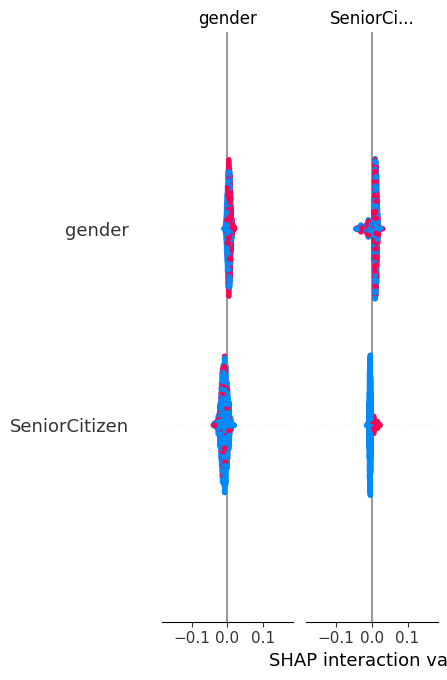

In [ ]:
import shap

explainer = shap.TreeExplainer(pipe_rf.named_steps['model'])
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)